                                         CLUSTERING ANALYSIS 

                       Understanding and Implementing K-Means and DBSCAN Algorithms

Objective:

The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.

Datasets :

Data Preprocessing:

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import	seaborn as sns
from sklearn.preprocessing import StandardScaler

In [19]:
df = pd.read_csv('Airlines.csv')

In [20]:
df

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_mile,flight_tran,day_since,Award
0,1,1000,5000,100,yes,high,300,3,10000,5,100,1
1,2,2000,6000,200,no,low,400,5,12000,6,200,0
2,3,3000,7000,250,yes,med,700,4,14000,7,400,0
3,4,4000,8000,300,no,low,750,2,15500,3,300,1
4,5,5000,9000,500,yes,high,900,1,16000,2,222,1


In [21]:
df.head()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_mile,flight_tran,day_since,Award
0,1,1000,5000,100,yes,high,300,3,10000,5,100,1
1,2,2000,6000,200,no,low,400,5,12000,6,200,0
2,3,3000,7000,250,yes,med,700,4,14000,7,400,0
3,4,4000,8000,300,no,low,750,2,15500,3,300,1
4,5,5000,9000,500,yes,high,900,1,16000,2,222,1


In [22]:
df.tail()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_mile,flight_tran,day_since,Award
0,1,1000,5000,100,yes,high,300,3,10000,5,100,1
1,2,2000,6000,200,no,low,400,5,12000,6,200,0
2,3,3000,7000,250,yes,med,700,4,14000,7,400,0
3,4,4000,8000,300,no,low,750,2,15500,3,300,1
4,5,5000,9000,500,yes,high,900,1,16000,2,222,1


In [23]:
df.columns

Index(['ID', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_mile', 'flight_tran', 'day_since',
       'Award'],
      dtype='object')

In [24]:
df.shape

(5, 12)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           5 non-null      int64 
 1   Balance      5 non-null      int64 
 2   Qual_miles   5 non-null      int64 
 3   cc1_miles    5 non-null      int64 
 4   cc2_miles    5 non-null      object
 5   cc3_miles    5 non-null      object
 6   Bonus_miles  5 non-null      int64 
 7   Bonus_trans  5 non-null      int64 
 8   Flight_mile  5 non-null      int64 
 9   flight_tran  5 non-null      int64 
 10  day_since    5 non-null      int64 
 11  Award        5 non-null      int64 
dtypes: int64(10), object(2)
memory usage: 608.0+ bytes


In [26]:
df.describe()

,ID,Balance,Qual_miles,cc1_miles,Bonus_miles,Bonus_trans,Flight_mile,flight_tran,day_since,Award
count,5.000000,5.00000,5.00000,5.00000,5.000000,5.000000,5.0,5.000000,5.000000,5.000000
mean,3.000000,3000.00000,7000.00000,270.00000,610.000000,3.000000,13500.0,4.600000,244.400000,0.600000
std,1.581139,1581.13883,1581.13883,148.32397,250.998008,1.581139,2500.0,2.073644,112.502444,0.547723
min,1.000000,1000.00000,5000.00000,100.00000,300.000000,1.000000,10000.0,2.000000,100.000000,0.000000
25%,2.000000,2000.00000,6000.00000,200.00000,400.000000,2.000000,12000.0,3.000000,200.000000,0.000000
50%,3.000000,3000.00000,7000.00000,250.00000,700.000000,3.000000,14000.0,5.000000,222.000000,1.000000
75%,4.000000,4000.00000,8000.00000,300.00000,750.000000,4.000000,15500.0,6.000000,300.000000,1.000000
max,5.000000,5000.00000,9000.00000,500.00000,900.000000,5.000000,16000.0,7.000000,400.000000,1.000000


In [27]:
df.isnull().sum()

ID             0
Balance        0
Qual_miles     0
cc1_miles      0
cc2_miles      0
cc3_miles      0
Bonus_miles    0
Bonus_trans    0
Flight_mile    0
flight_tran    0
day_since      0
Award          0
dtype: int64

In [28]:
df = df.dropna()

In [30]:
numeric_cols = ['Balance', 'Qual_miles', 'Bonus_miles', 'Flight_mile', 'day_since']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

In [31]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

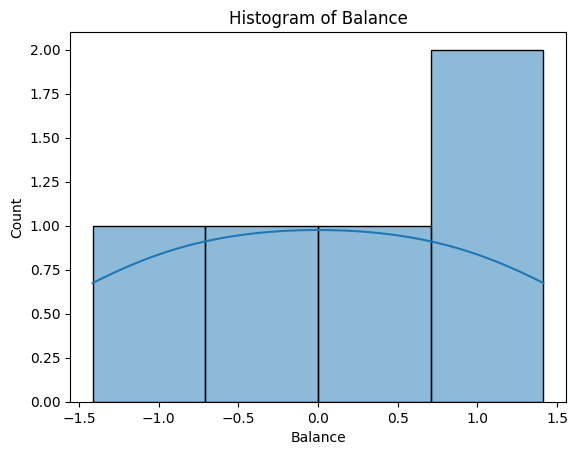

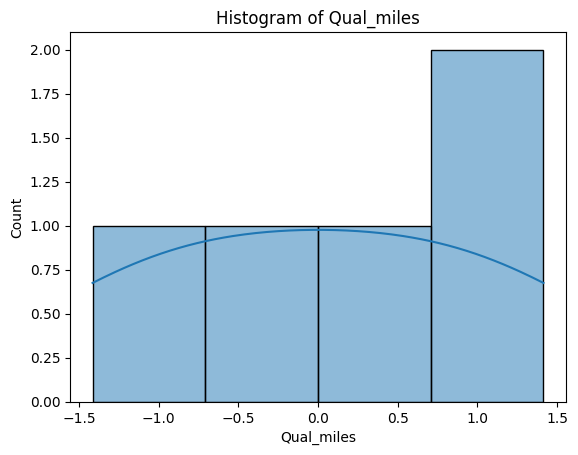

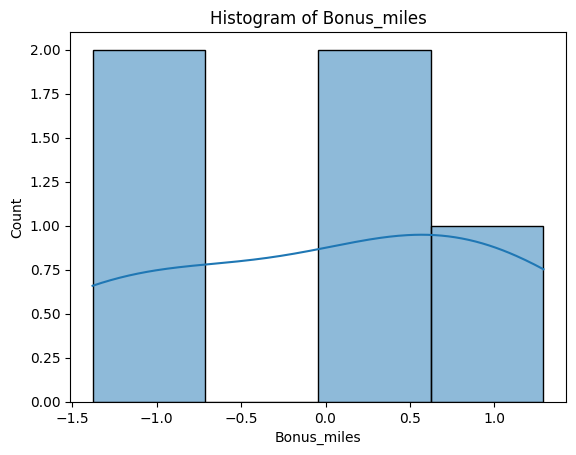

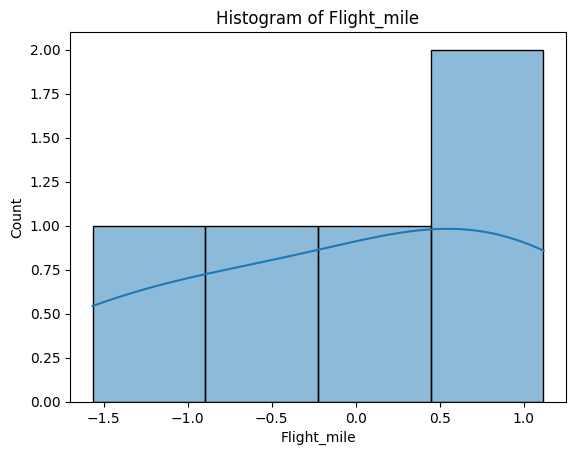

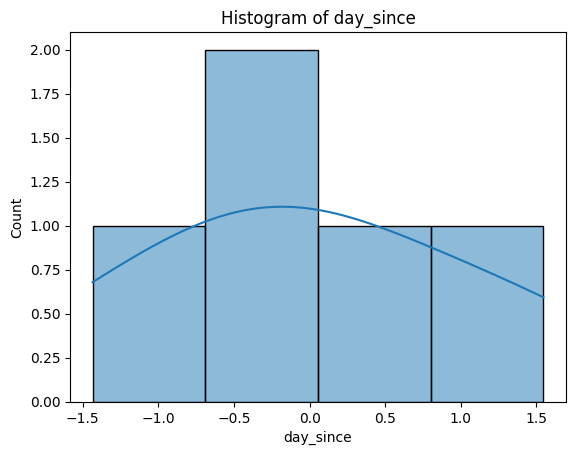

In [34]:
for	col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

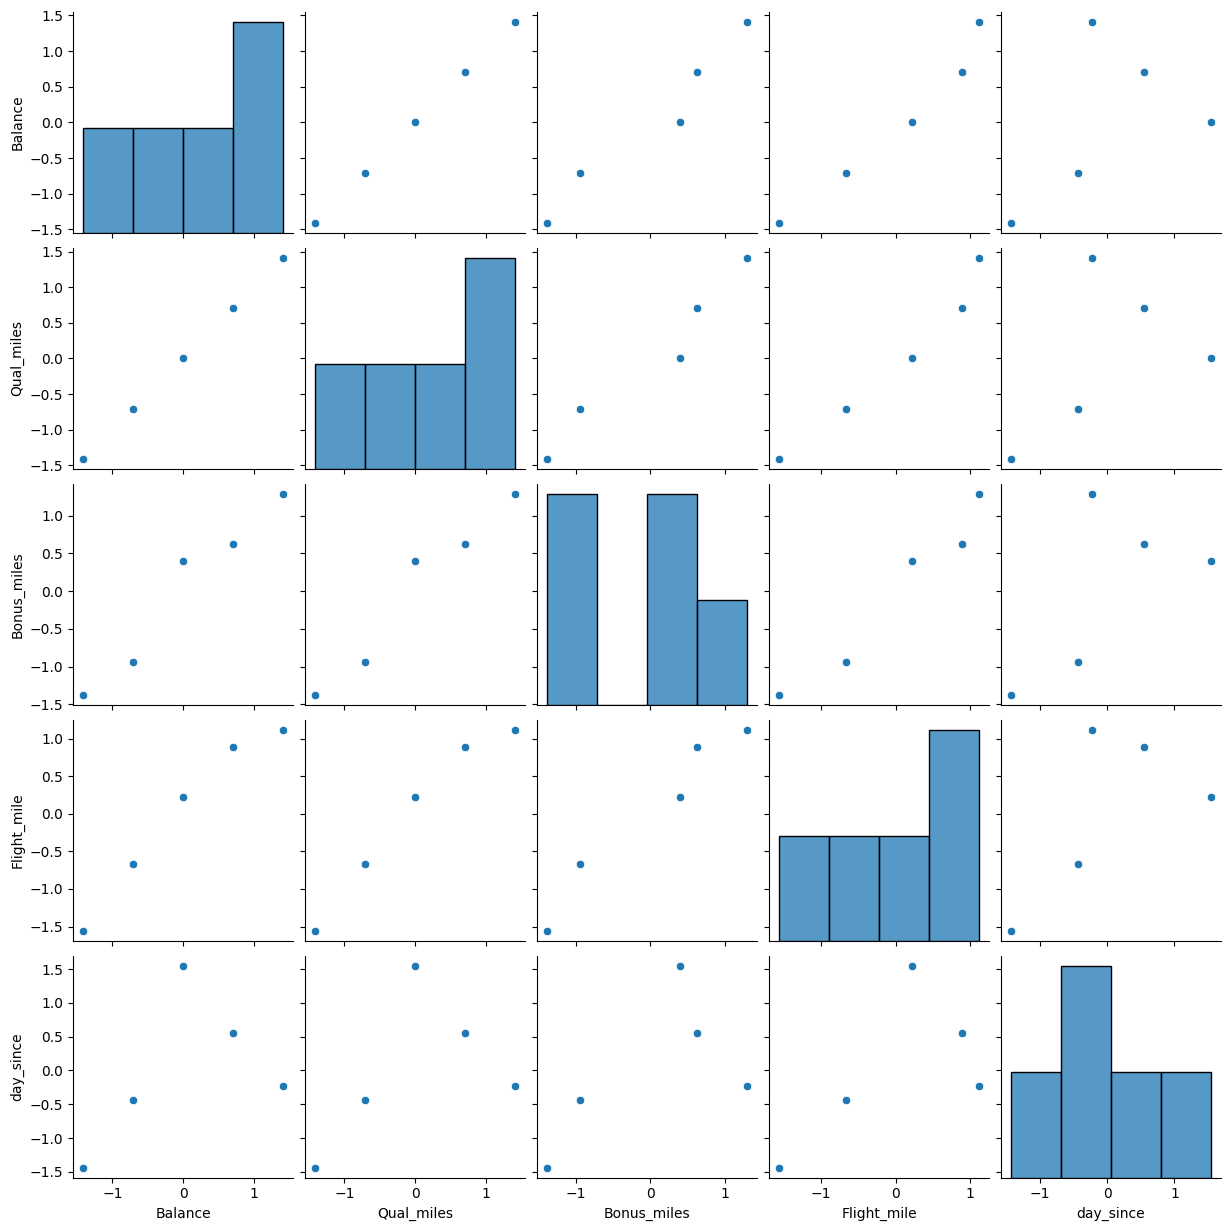

In [32]:
sns.pairplot(df[numeric_cols])
plt.show()


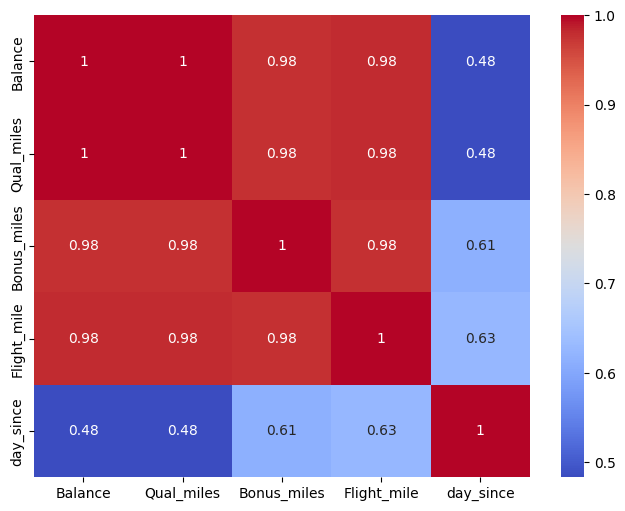

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

Implementing Clustering Algorithms:

•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.


In [35]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [36]:
numeric_cols = ['Balance', 'Qual_miles', 'Bonus_miles', 'Flight_mile', 'day_since']
X = df[numeric_cols]

In [73]:
inertia = []
silhouette = []
K_range = range(2, 6)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)


In [75]:
n_clusters = min(4, len(X) - 2)  # ensure valid cluster count
kmeans = KMeans(n_clusters=n_clusters)
labels = kmeans.fit_predict(X)
if len(np.unique(labels)) >= 2:
    silhouette.append(silhouette_score(X, labels))

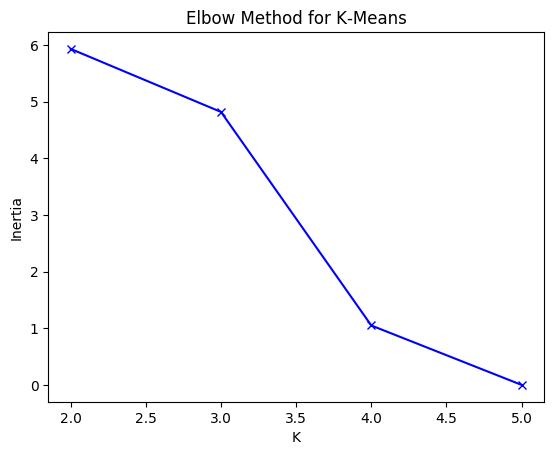

In [38]:
# Plot Elbow curve
plt.figure()
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method for K‑Means')
plt.show()

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
kmeans_silhouette = silhouette_score(X, kmeans_labels)
print(f"K‑Means Silhouette Score: {kmeans_silhouette:.3f}")

K‑Means Silhouette Score: 0.087


In [76]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)


In [78]:
# Silhouette score (exclude noise points, label -1)
dbscan_valid = dbscan_labels != -1
if len(np.unique(dbscan_labels[dbscan_valid])) > 1:
    dbscan_silhouette = silhouette_score(X[dbscan_valid], dbscan_labels[dbscan_valid])
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.3f}")
else:
    print("Not enough clusters to compute silhouette score for DBSCAN.")

Not enough clusters to compute silhouette score for DBSCAN.


In [79]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

Text(0.5, 1.0, 'K‑Means Clusters')

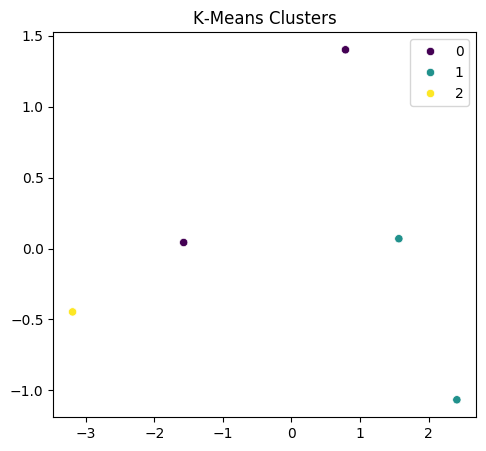

In [80]:
plt.figure(figsize=(12, 5))
# K‑Means plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='viridis')
plt.title('K‑Means Clusters')


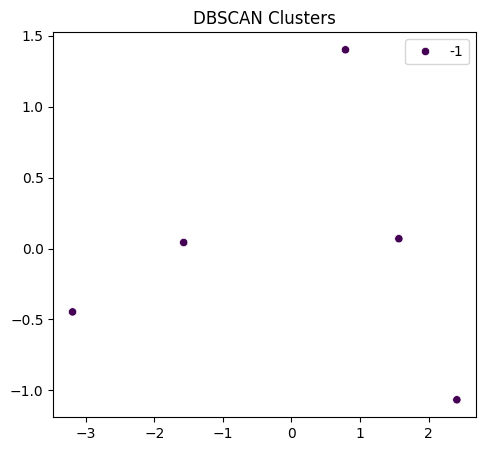

In [81]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=dbscan_labels, palette='viridis')
plt.title('DBSCAN Clusters')
plt.show()

Cluster Analysis and Interpretation:

•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


In [82]:
# K-Means cluster characteristics
kmeans_cluster_df = df[numeric_cols].copy()
kmeans_cluster_df['Cluster'] = kmeans_labels


In [83]:
print("K-Means Cluster Characteristics:")
print(kmeans_cluster_df.groupby('Cluster').mean())

K-Means Cluster Characteristics:
          Balance  Qual_miles  Bonus_miles  Flight_mile  day_since
Cluster                                                           
0       -0.353553   -0.353553    -0.267261    -0.223607   0.552545
1        1.060660    1.060660     0.957686     1.006231   0.164969
2       -1.414214   -1.414214    -1.380850    -1.565248  -1.435028


In [84]:
# DBSCAN cluster characteristics
dbscan_cluster_df = df[numeric_cols].copy()
dbscan_cluster_df['Cluster'] = dbscan_labels


In [85]:

print("DBSCAN Cluster Characteristics:")
print(dbscan_cluster_df.groupby('Cluster').mean())

DBSCAN Cluster Characteristics:
         Balance  Qual_miles  Bonus_miles  Flight_mile     day_since
Cluster                                                             
-1           0.0         0.0          0.0          0.0 -7.771561e-17


Visualization:

Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.


Text(0.5, 1.0, 'K-Means Clusters')

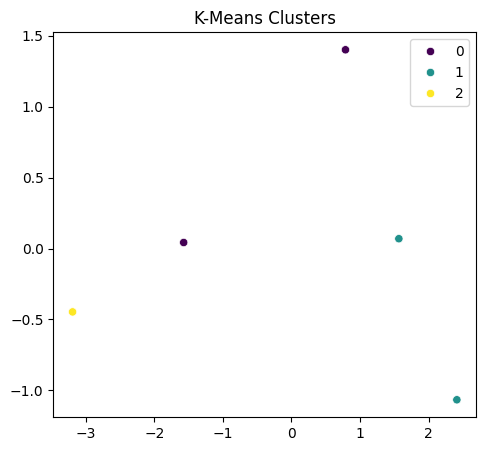

In [86]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='viridis')
plt.title('K-Means Clusters')

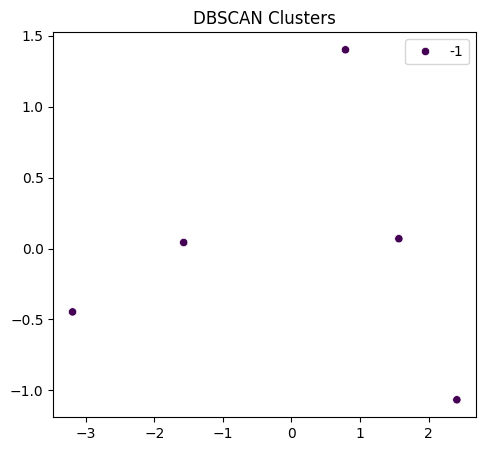

In [87]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=dbscan_labels, palette='viridis')
plt.title('DBSCAN Clusters')
plt.show()

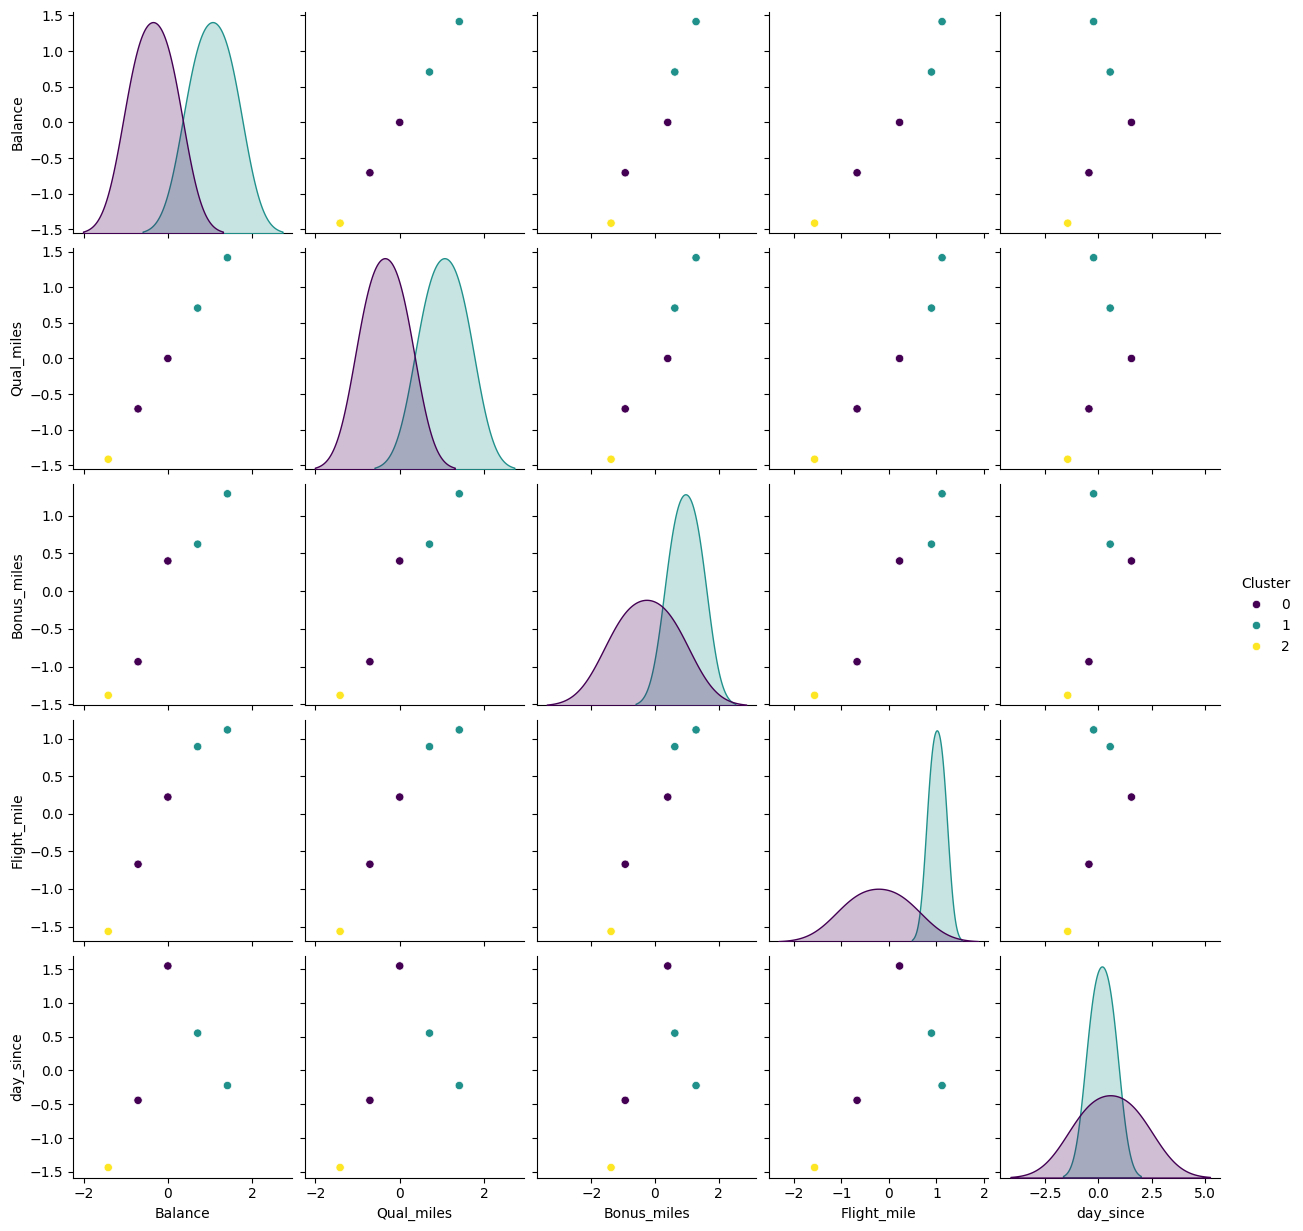

In [88]:
# Pairplot for K-Means clusters
kmeans_cluster_df = df[numeric_cols].copy()
kmeans_cluster_df['Cluster'] = kmeans_labels
sns.pairplot(kmeans_cluster_df, hue='Cluster', palette='viridis')
plt.show()


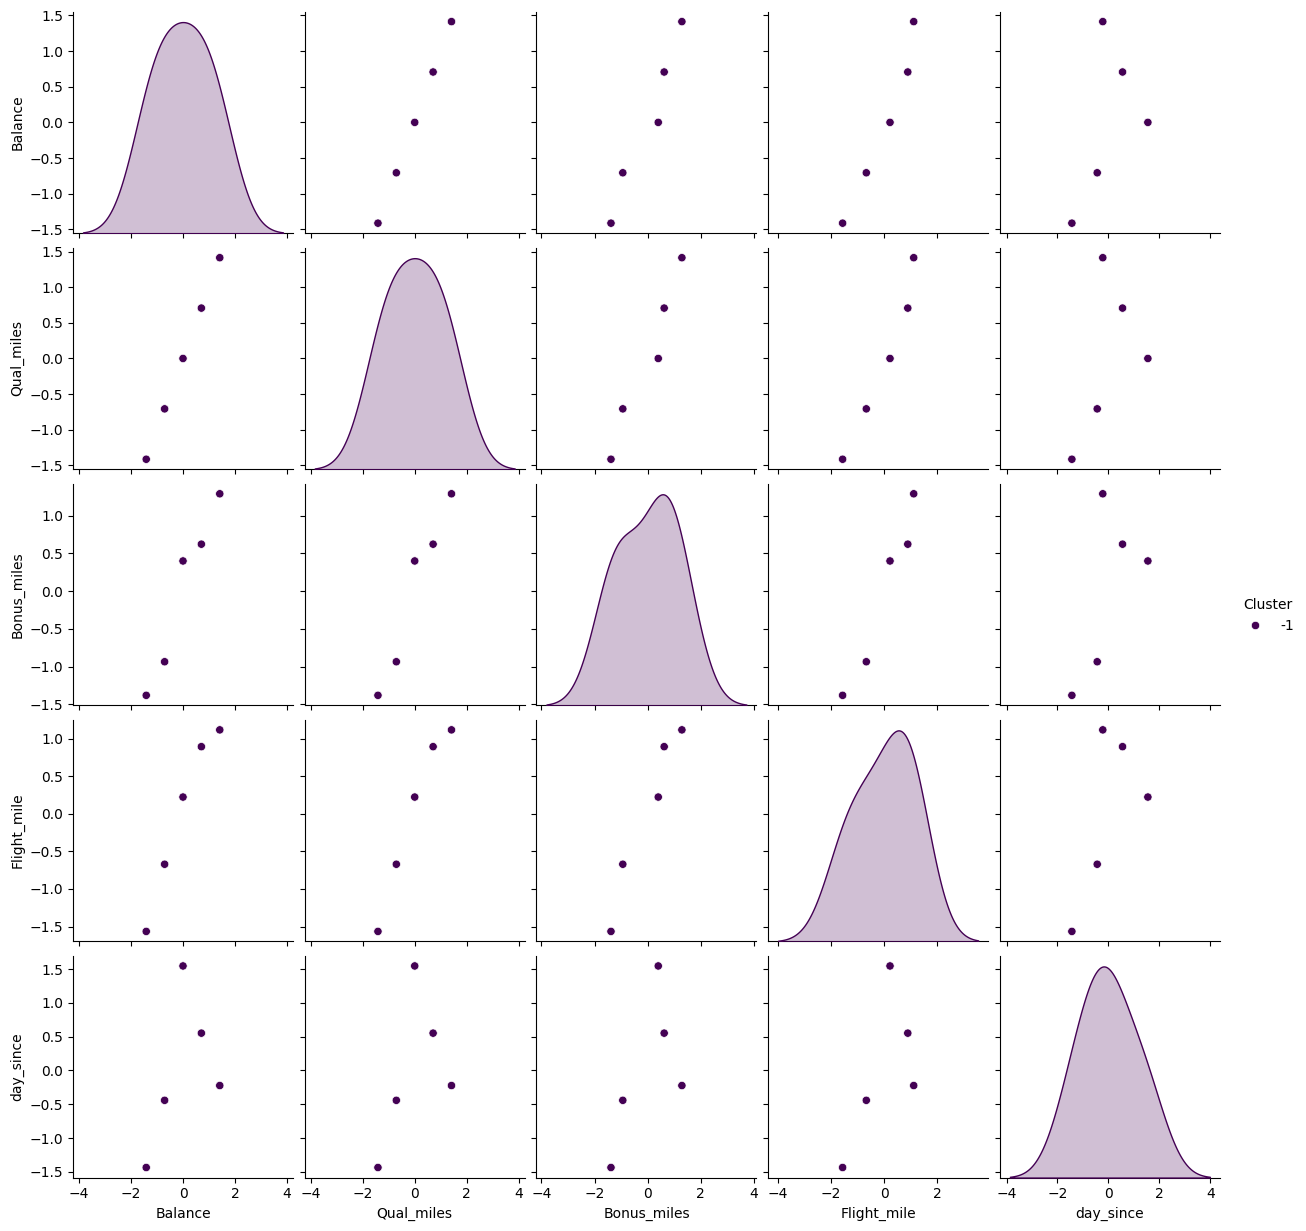

In [89]:
# Pairplot for DBSCAN clusters
dbscan_cluster_df = df[numeric_cols].copy()
dbscan_cluster_df['Cluster'] = dbscan_labels
sns.pairplot(dbscan_cluster_df, hue='Cluster', palette='viridis')
plt.show()

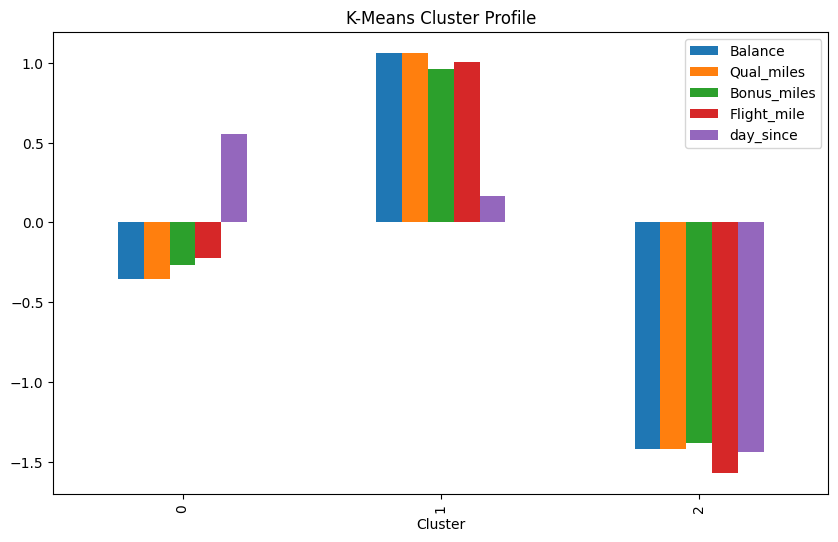

In [92]:
# Cluster profile plot for K-Means
kmeans_cluster_df.groupby('Cluster').mean().plot(kind='bar', figsize=(10, 6))
plt.title('K-Means Cluster Profile')
plt.show()


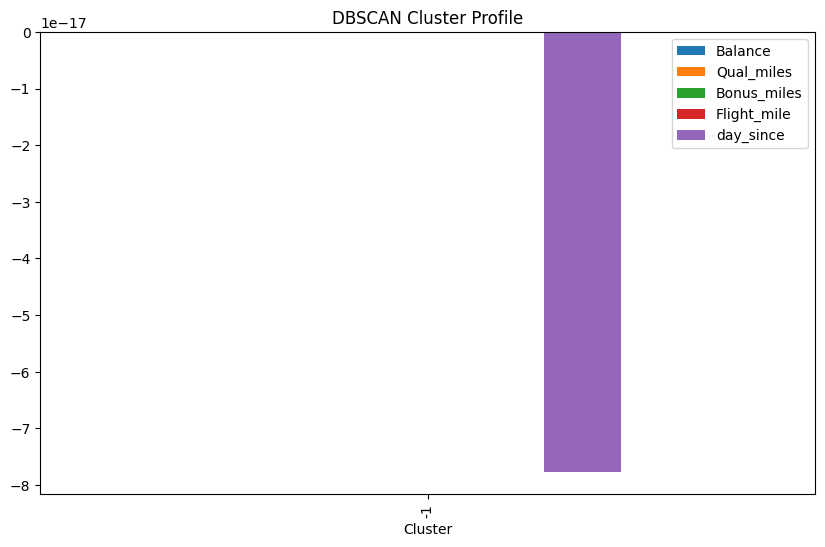

In [93]:

# Cluster profile plot for DBSCAN
dbscan_cluster_df.groupby('Cluster').mean().plot(kind='bar', figsize=(10, 6))
plt.title('DBSCAN Cluster Profile')
plt.show()

Evaluation and Performance Metrics:

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [94]:
# K-Means silhouette score
kmeans_silhouette = silhouette_score(X, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette:.3f}")


K-Means Silhouette Score: 0.087


In [96]:

# DBSCAN silhouette score (excluding noise points)
dbscan_valid = dbscan_labels != -1
if len(np.unique(dbscan_labels[dbscan_valid])) > 1:
    dbscan_silhouette = silhouette_score(X[dbscan_valid], dbscan_labels[dbscan_valid])
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.3f}")
else:
    print("Not enough clusters to compute silhouette score for DBSCAN.")

Not enough clusters to compute silhouette score for DBSCAN.


In [97]:
from sklearn.metrics import calinski_harabasz_score


In [98]:

# K-Means Calinski-Harabasz Index
kmeans_ch = calinski_harabasz_score(X, kmeans_labels)
print(f"K-Means Calinski-Harabasz Index: {kmeans_ch:.3f}")

K-Means Calinski-Harabasz Index: 4.190


In [100]:
# DBSCAN Calinski-Harabasz Index (excluding noise points)
if len(np.unique(dbscan_labels[dbscan_valid])) > 1:
    dbscan_ch = calinski_harabasz_score(X[dbscan_valid], dbscan_labels[dbscan_valid])
    print(f"DBSCAN Calinski-Harabasz Index: {dbscan_ch:.3f}")
else:
    print("Not enough clusters to compute Calinski-Harabasz index for DBSCAN.")

Not enough clusters to compute Calinski-Harabasz index for DBSCAN.


In [101]:
from sklearn.metrics import davies_bouldin_score
import warnings
warnings.filterwarnings("ignore")

In [102]:

# K-Means Davies-Bouldin Index
kmeans_db = davies_bouldin_score(X, kmeans_labels)
print(f"K-Means Davies-Bouldin Index: {kmeans_db:.3f}")


K-Means Davies-Bouldin Index: 0.673


In [106]:
# DBSCAN Davies-Bouldin Index (excluding noise points)
dbscan_valid = dbscan_labels[dbscan_labels != -1]
if len(np.unique(dbscan_labels[dbscan_valid])) > 1:
    dbscan_db = davies_bouldin_score(X[dbscan_valid], dbscan_labels[dbscan_valid])
    print(f"DBSCAN Davies-Bouldin Index: {dbscan_db:.3f}")
else:
    print("Not enough clusters to compute Davies-Bouldin index for DBSCAN.")

Not enough clusters to compute Davies-Bouldin index for DBSCAN.
